# Improving NNs

In [1]:
# Import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

# Set print options for PyTorch tensors
torch.set_printoptions(precision=2, linewidth=50000, profile="full", sci_mode=False)

# Load the dataset
train_ds = MNIST(root="../data", train=True, download=True, transform=ToTensor())

train_x = []
train_y = []

for img, label in train_ds:
    train_x.append(img)
    train_y.append(label)

# Conver the lists to PyTorch tensors
train_x = torch.stack(train_x)
train_y = torch.tensor(train_y)

# Flatten images
X = train_x.view(-1, 784) # 784 = 1 x 28 x 28


def print_log(log):
    """
    Print formatted training log table.
    
    Parameters:
        log (str): Formatted log string with one line per epoch.
    """
    print(f"| {'Epoch':^5} | {'Train Loss':^10} |")
    print(f"|{'-'*7}|{'-'*12}|")
    print(log)

## loss.backward()

We can simplify the implementation of the previous neural networks using PyTorch.

```{admonition} Help
:class: dropdown
`p.requires_grad = True` instructs PyTorch to track the gradient of the loss for those parameters. This enables us to use `loss.backward()` during the backward pass to calculate the gradient automatically.
```

In [8]:
def initialize_nn(n_hidden=100):

    g = torch.Generator().manual_seed(1)
    
    W1 = torch.randn((784, n_hidden),      generator=g)
    b1 = torch.zeros(n_hidden)
    W2 = torch.randn((n_hidden, n_hidden), generator=g)
    b2 = torch.zeros(n_hidden)
    W3 = torch.randn((n_hidden, 10),       generator=g)
    b3 = torch.zeros(10)
    
    parameters = [W1, b1, W2, b2, W3, b3]
    
    for p in parameters:
        p.requires_grad = True      # Track the gradient
        
    return parameters

```{admonition} Help
:class: dropdown
We can also use the PyTorch function `F.cross_entropy()`, which efficiently applies Softmax and the average NLL.
```

In [9]:
# Hyperparameters
epochs = 100        # Number of times the dataset is fully seen
lr = 0.1            # Learning rate


# Intialize model
parameters = initialize_nn()
W1, b1, W2, b2, W3, b3 = parameters
log = ""
train_losses = []


# Train model
for epoch in range(epochs):
    
    # Forward pass
    h1 = torch.tanh(X @ W1 + b1)
    h2 = torch.tanh(h1 @ W2 + b2)
    logits = h2 @ W3 + b3

    # Calculate loss
    loss = F.cross_entropy(logits, train_y) # Softmax + Average NNL
    train_loss = loss.item()
    train_losses.append(train_loss)
    
    # Backward pass
    for p in parameters:
        p.grad = None       # Reset gradient
    loss.backward()         # Calculate gradient
    
    # Update parameters
    for p in parameters:
        p.data += -lr * p.grad
    
    # Print loss
    if epoch == 0 or (epoch + 1) % 20 == 0 or (epoch + 1) == epochs:
        log += f"| {epoch+1:^5} | {train_loss:^10.4f} |\n"

print_log(log)

| Epoch | Train Loss |
|-------|------------|
|   1   |  15.9699   |
|  20   |   8.5526   |
|  40   |   5.7175   |
|  60   |   4.3916   |
|  80   |   3.6685   |
|  100  |   3.2024   |



As shown in the graphs below, the neural network is progressively reducing the loss, and therfore learning!

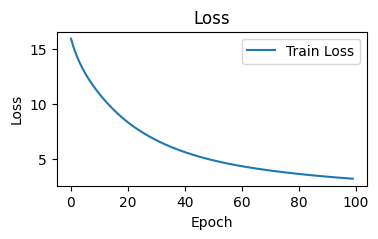

In [10]:
plt.figure(figsize=(4, 2))
plt.plot(train_losses, label="Train Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title("Loss")
plt.show()

## Test Dataset

In [11]:
# Load the dataset
test_ds = MNIST(root="../data", train=False, download=True, transform=ToTensor())

test_x = []
test_y = []

for img, label in test_ds:
    test_x.append(img)
    test_y.append(label)

# Conver the lists to PyTorch tensors
test_x = torch.stack(test_x)
test_y = torch.tensor(test_y)

# Flatten images
test_x = test_x.view(-1, 784) # 784 = 1 x 28 x 28

In [ ]:
@torch.no_grad()
def evaluate():

    # Forward pass
    h1 = torch.tanh(test_x @ W1 + b1)
    h2 = torch.tanh(h1 @ W2 + b2)
    logits = h2 @ W3 + b3

    # Calculate loss
    test_loss = F.cross_entropy(logits, test_y)

    # Calculate accuracy
    preds = logits.argmax(dim=1)
    test_accuracy = (preds == test_y).float().mean()

    return test_loss, test_accuracy

After seeing all the images 100 times, the model only predicts the correct number 52% of the time.

In [17]:
test_loss, test_accuracy = evaluate()
print(f"Test Loss: {test_loss:.4f}    Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 3.2592    Test Accuracy: 52.52%


## Mini-batches

&ensp; &ensp; &ensp; &ensp;Appart from the low accuracy, the issue with the previous neural network is that each epoch took a considerable amount of time. Processing the entire dataset of 60,000 images in every epoch is computationally expensive. I know your computer was able to run the script in just a few seconds. But keep in mind that soon we’ll be working with much more complex models. To address this problem, we’ll use **mini-batches**, small subsets of the training dataset.

``````{important}
To create the mini-batches, I will shuffle the entire dataset once at the start of each epoch and then process it sequentially in batches. This is the most common approach used in frameworks like PyTorch and TensorFlow. 

However, you might also encounter people just sampling and processing a single random batch at each epoch. Here is how the code of that simplistic approach would look like:

```python
for epoch in range(epochs):
    
    # Create mini-batch
    indices = torch.randint(0, N, (batch_size,), generator=g)
    Xb, Yb = Xtr[indices], Ytr[indices]

    # forward pass
    h1 = torch.tanh(Xb @ W1 + b1)
    ...
```
``````

```{admonition} Help
:class: dropdown
`torch.randint(0, N, (batch_size,))` randomly generates 32 integers between 0 and 60000 that we will use to index into the dataset.
```

In [21]:
# Hyperparameters
epochs = 5          # Number of times the dataset is fully seen
batch_size = 32     # Number of examples per batch
lr = 0.1            # Learning rate


# Initialize model
parameters = initialize_nn()
W1, b1, W2, b2, W3, b3 = parameters
log = ""


g = torch.Generator().manual_seed(1)
N = X.shape[0]
steps = N // batch_size  # Number of mini-batches


# Train model
for epoch in range(epochs):

    running_train_loss = 0

    # Shuffle dataset at the start of each epoch
    indices = torch.randperm(N, generator=g)
    X_shuffled = X[indices]
    Y_shuffled = train_y[indices]

    for step in range(steps):

        # Create mini-batch
        start = step * batch_size
        end = start + batch_size
        Xb = X_shuffled[start:end]
        Yb = Y_shuffled[start:end]

        # Forward pass
        h1 = torch.tanh(Xb @ W1 + b1)  # (32, 100) = (32, 784) x (784, 100) + (100)
        h2 = torch.tanh(h1 @ W2 + b2)  # (32, 100) = (32, 100) x (100, 100) + (100)
        logits = h2 @ W3 + b3          # (32,  10) = (32, 100) x (100,  10) + (10)
        
        # Calculate loss
        loss = F.cross_entropy(logits, Yb)
        running_train_loss += loss.item()  # Accumulate loss

        # Backward pass
        for p in parameters:
            p.grad = None
        loss.backward()

        # Update parameters
        for p in parameters:
            p.data += -lr * p.grad
    
    
    train_loss = running_train_loss / steps
    log += f"| {epoch+1:^5} | {train_loss:^10.4f} |\n"

print_log(log)

| Epoch | Train Loss |
|-------|------------|
|   1   |   1.4729   |
|   2   |   0.5610   |
|   3   |   0.4248   |
|   4   |   0.3605   |
|   5   |   0.3152   |



## DataLoader()

PyTorch also provides DataLoader to simplify and make more efficient how we crate the batches

In [22]:
# Load the dataset
train_ds = MNIST(root="../data", train=True,  download=True, transform=ToTensor())
test_ds  = MNIST(root="../data", train=False, download=True, transform=ToTensor())

# Create a DataLoader with batching and shuffling
g = torch.Generator().manual_seed(1)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=g)
test_loader  = DataLoader(test_ds,  batch_size=batch_size)

In [23]:
# Initialize model
parameters = initialize_nn()
W1, b1, W2, b2, W3, b3 = parameters
log = ""


# Train model
for epoch in range(epochs):

    running_train_loss = 0

    for Xb, Yb in train_loader:

        Xb = Xb.view(-1,784)  # Flatten 28x28 to 784

        # Forward pass
        h1 = torch.tanh(Xb @ W1 + b1)  # (32, 100) = (32, 784) x (784, 100) + (100)
        h2 = torch.tanh(h1 @ W2 + b2)  # (32, 100) = (32, 100) x (100, 100) + (100)
        logits = h2 @ W3 + b3          # (32,  10) = (32, 100) x (100,  10) + (10)

        # Calculate loss
        loss = F.cross_entropy(logits, Yb)
        running_train_loss += loss.item()  # Accumulate loss

        # Backward pass
        for p in parameters:
            p.grad = None
        loss.backward()

        # Update parameters
        for p in parameters:
            p.data += -lr * p.grad
    
    train_loss = running_train_loss / steps
    log += f"| {epoch+1:^5} | {train_loss:^10.4f} |\n"

print_log(log)

| Epoch | Train Loss |
|-------|------------|
|   1   |   1.5072   |
|   2   |   0.5634   |
|   3   |   0.4391   |
|   4   |   0.3763   |
|   5   |   0.3344   |



Those are the average loss of each epoch. After training, we can evaulate our model computing the loss and accuarcy of the entire training dataset.

In [24]:
@torch.no_grad()
def evaluate():
    total_loss = 0
    total_correct = 0
    total_samples = 0

    for Xb, Yb in test_loader:
        Xb = Xb.view(-1,784)  # Flatten 28x28 to 784

        # Forward pass
        h1 = torch.tanh(Xb @ W1 + b1)
        h2 = torch.tanh(h1 @ W2 + b2)
        logits = h2 @ W3 + b3

        # Calculate loss
        loss = F.cross_entropy(logits, Yb, reduction='sum')
        total_loss += loss.item()

        # Calculate accuracy
        total_correct += (logits.argmax(dim=1) == Yb).sum().item()

        # Count samples
        total_samples += Yb.size(0)
    
    return total_loss / total_samples, total_correct / total_samples

Please note that the model is now only seeing all the images 5 times but it got an acccuracy of 88%! This clearly shows that using mini-batches during training is more efficient and leads to better results.

In [25]:
test_loss, test_accuracy = evaluate()
print(f"Test Loss: {test_loss:.4f}    Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.3848    Test Accuracy: 88.38%


## Saturated Softmax

Our neural network is facing several issues that are hindering its learning process. Let's just calculate the batch loss of the first step. We will refer to it as the intialization loss.

In [ ]:
# Initialize model
parameters = initialize_nn()
W1, b1, W2, b2, W3, b3 = parameters


# Train model
for epoch in range(epochs):

    for Xb, Yb in train_loader:

        Xb = Xb.view(-1,784)

        # Forward pass
        h1 = torch.tanh(Xb @ W1 + b1)
        h2 = torch.tanh(h1 @ W2 + b2)
        logits = h2 @ W3 + b3
        probs = logits.exp() / logits.exp().sum(1, keepdims=True)

        # Calculate loss
        loss = -probs[range(batch_size), Yb].log().mean()

        print(f"Intialization Loss: {loss:.4f}")

        break

    break

Intialization Loss: 13.4702


At initialization, the model should assign roughly equal probabilities (1/10) to all classes. Therefore, we would expect the initialization loss to be approximately:

<br>

$$
\text{Initialization Loss:} = -\log\left(\frac{1}{10}\right) = 2.3026
$$

<br>

However, we obtained an itilization loss of 11.3392. The issue is that the Softmax function is saturated because the logits produced by the neural network are extremely positive or negative. When these extreme values are passed through the Softmax function, they result in probabilities close to 0 or 1. The problem is that the model is often assigning a very high probability to the incorrect class at initialization, leading to a significantly high loss.

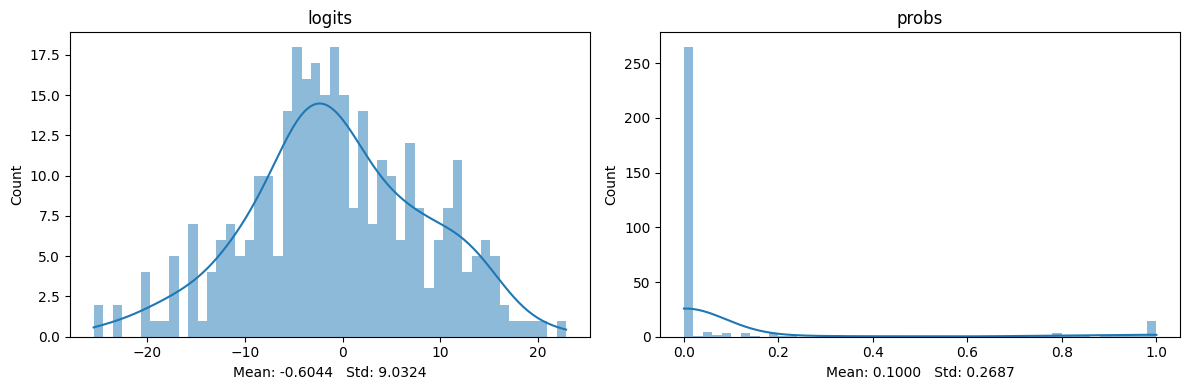

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(121)
sns.histplot(logits.view(-1).tolist(), bins=50, kde=True, edgecolor='none');
plt.title('logits')
plt.xlabel(f'Mean: {logits.mean():.4f}   Std: {logits.std():.4f}')

plt.subplot(122)
sns.histplot(probs.view(-1).tolist(), bins=50, kde=True, edgecolor='none');
plt.title('probs')
plt.xlabel(f'Mean: {probs.mean():.4f}   Std: {probs.std():.4f}')

plt.tight_layout()

To address the saturated Softmax issue, we will scale the weights of the last layer by a factor of 0.01.

In [ ]:
def initialize_nn(n_hidden = 100):

    g = torch.Generator().manual_seed(1)
    
    W1 = torch.randn((784, n_hidden),      generator=g)
    b1 = torch.zeros(n_hidden)
    W2 = torch.randn((n_hidden, n_hidden), generator=g)
    b2 = torch.zeros(n_hidden)
    W3 = torch.randn((n_hidden, 10),       generator=g) * 0.01  # Scale weights of last layer
    b3 = torch.zeros(10)
    
    parameters = [W1, b1, W2, b2, W3, b3]

    for p in parameters:
        p.requires_grad = True
    
    return parameters

In [ ]:
# Initialize model
parameters = initialize_nn()
W1, b1, W2, b2, W3, b3 = parameters


# Train model
for epoch in range(epochs):

    for Xb, Yb in train_loader:

        Xb = Xb.view(-1,784)

        # Forward pass
        h1 = torch.tanh(Xb @ W1 + b1)
        h2 = torch.tanh(h1 @ W2 + b2)
        logits = h2 @ W3 + b3
        probs = logits.exp() / logits.exp().sum(1, keepdims=True)

        # Calculate loss
        loss = -probs[range(batch_size), Yb].log().mean()

        print(f"Intialization Loss: {loss:.4f}")

        break

    break

Intialization Loss: 2.3034


As we can see in the graphs below, With this adjustment the logits produced by the neural network are closer to 0, leading to more balanced probabilities (approximately 1/10) across all classes. Our initilazation loss (2.3147) is now very close to the one we expected (2.3026).

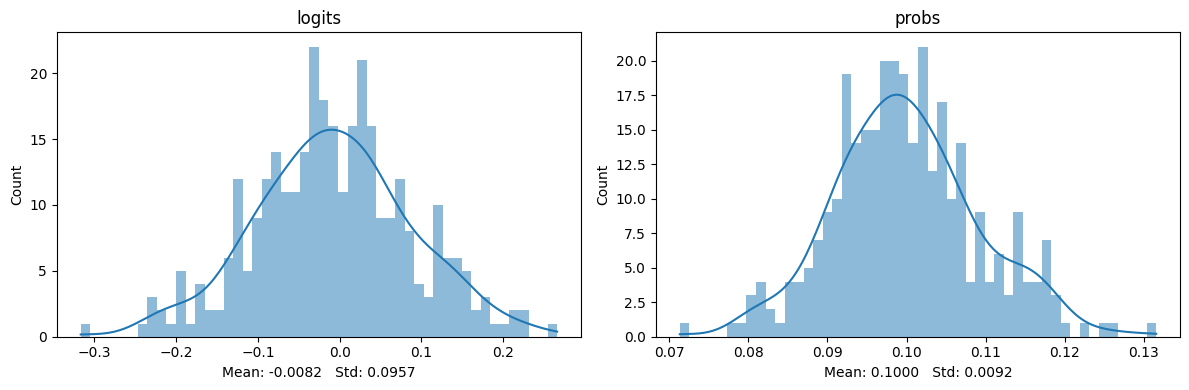

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(121)
sns.histplot(logits.view(-1).tolist(), bins=50, kde=True, edgecolor='none');
plt.title('logits')
plt.xlabel(f'Mean: {logits.mean():.4f}   Std: {logits.std():.4f}')

plt.subplot(122)
sns.histplot(probs.view(-1).tolist(), bins=50, kde=True, edgecolor='none');
plt.title('probs')
plt.xlabel(f'Mean: {probs.mean():.4f}   Std: {probs.std():.4f}')

plt.tight_layout()

## Saturated Tanh

The Tanh activation function becomes saturated when neuron pre-activations are extremely positive or negative. In such cases, the Tanh function returns activations that are approximately 1 and -1, as shown in the graph below:

```{figure} ../images/tanh.png
---
width: 300px
name: tanh
---
tanh (Hyperbolic Tangent). Source: {cite}`weisstein_tanh`
```

Approximately 1 and -1 activations make the gradient approximately 0 when we backpropagate through Tanh:

<br>

$$
h2 = tanh(h2\_pre) \quad \Rightarrow \quad dh2\_pre = (1 - (h2)^2) \cdot dh2 \\
h1 = tanh(h1\_pre) \quad \Rightarrow \quad dh1\_pre = (1 - (h1)^2) \cdot dh1
$$

The problem with an approximately 0 gradient is that the network barely updates its parameters slowing down learning.

Let's run a single step:

In [ ]:
# Intialize model
parameters = initialize_nn()
W1, b1, W2, b2, W3, b3 = parameters


# Train model
for epoch in range(epochs):

    for Xb, Yb in train_loader:

        Xb = Xb.view(-1,784)
        
        # Forward pass
        h1_pre = Xb @ W1 + b1       # 1st layer pre-activations
        h1 = torch.tanh(h1_pre)
        h1_pre.retain_grad()        # Track gradient

        h2_pre = h1 @ W2 + b2       # 2nd layer pre-activations
        h2 = torch.tanh(h2_pre)
        h2_pre.retain_grad()        # Track gradient

        logits = h2 @ W3 + b3 

        # Calculate loss
        loss = F.cross_entropy(logits, Yb)

        # Backward pass
        for p in parameters:
            p.grad = None
        loss.backward()

        break

    break

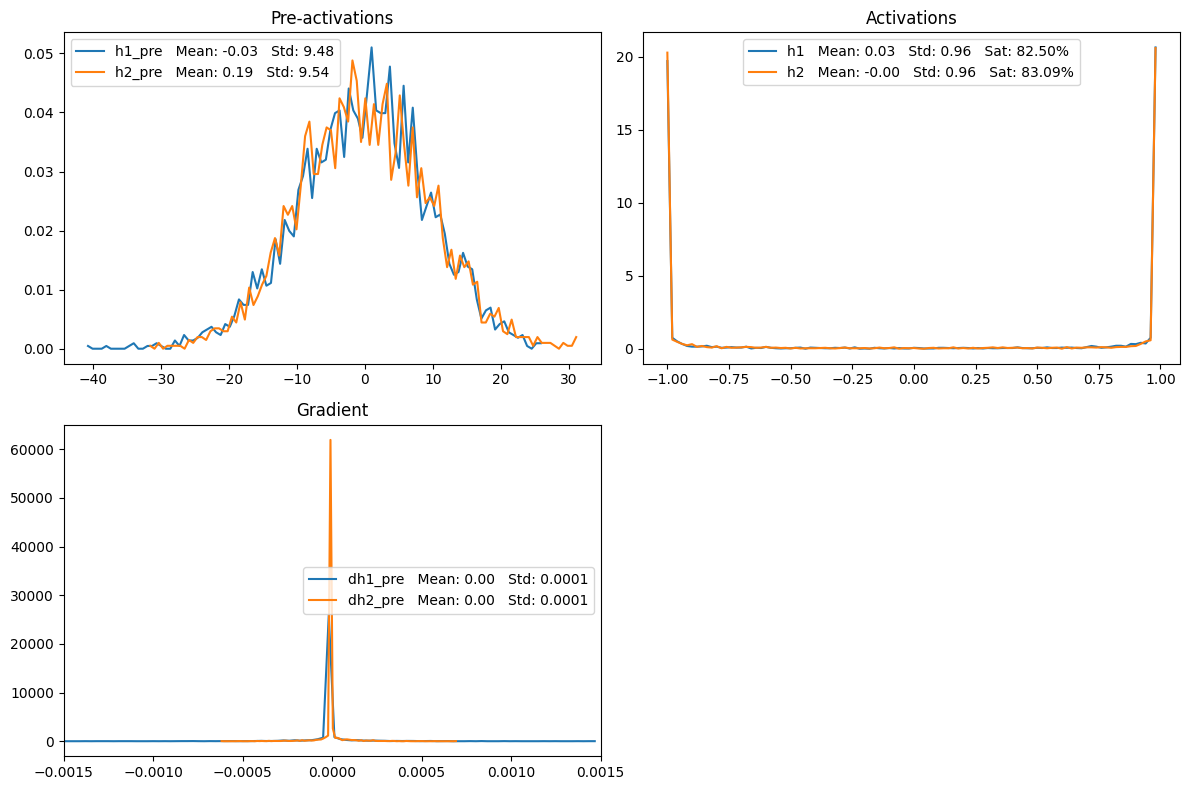

In [ ]:
plt.figure(figsize=(12,8))

# Pre-activations distribution
plt.subplot(221)
hy, hx = torch.histogram(h1_pre, density=True)
plt.plot(hx[:-1].detach(), hy.detach(), label=f'h1_pre   Mean: {h1_pre.mean():.2f}   Std: {h1_pre.std():.2f}')
hy, hx = torch.histogram(h2_pre, density=True)
plt.plot(hx[:-1].detach(), hy.detach(), label=f'h2_pre   Mean: {h2_pre.mean():.2f}   Std: {h2_pre.std():.2f}')
plt.title('Pre-activations')
plt.legend()

# Activations distribution
plt.subplot(222)
hy, hx = torch.histogram(h1, density=True)
plt.plot(hx[:-1].detach(), hy.detach(), label=f'h1   Mean: {h1.mean():.2f}   Std: {h1.std():.2f}   Sat: {(h1.abs() > 0.97).float().mean()*100:.2f}%')
hy, hx = torch.histogram(h2, density=True)
plt.plot(hx[:-1].detach(), hy.detach(), label=f'h2   Mean: {h2.mean():.2f}   Std: {h2.std():.2f}   Sat: {(h2.abs() > 0.97).float().mean()*100:.2f}%')
plt.title('Activations')
plt.legend()

# Gradients distribution
plt.subplot(223)
hy, hx = torch.histogram(h1_pre.grad, density=True)
plt.plot(hx[:-1].detach(), hy.detach(), label=f'dh1_pre   Mean: {h1_pre.grad.mean():.2f}   Std: {h1_pre.grad.std():.4f}')
hy, hx = torch.histogram(h2_pre.grad, density=True)
plt.plot(hx[:-1].detach(), hy.detach(), label=f'dh2_pre   Mean: {h2_pre.grad.mean():.2f}   Std: {h2_pre.grad.std():.4f}')
plt.title('Gradient')
plt.xlim(-0.0015, 0.0015)
plt.legend()

plt.tight_layout()

## Kaiming initialization
 
**Kaiming initialization**, also known as He initialization, is a method for initializing neural network weights to avoid excessively large or small pre-activations. It was introduced in the paper [He et al. (2015). *Delving Deep into Rectifiers*](https://arxiv.org/pdf/1502.01852). Kaiming initialization adjusts the weights using a scaling factor determined by the activation function's gain and the number of inputs to the neuron, $fan\_in$.

<br>

$$
W \sim \frac{\text{gain}}{\sqrt{fan\_in}}
$$

In [26]:
def initialize_nn(n_hidden = 100):

    g = torch.Generator().manual_seed(1)
    
    W1 = torch.randn((784, n_hidden),      generator=g) * (5/3) / 784**0.5      # Kaiming initialization  
    b1 = torch.zeros(n_hidden)
    W2 = torch.randn((n_hidden, n_hidden), generator=g) * (5/3) / n_hidden**0.5 # Kaiming initialization
    b2 = torch.zeros(n_hidden)
    W3 = torch.randn((n_hidden, 10),       generator=g) * 0.01
    b3 = torch.zeros(10)
    
    parameters = [W1, b1, W2, b2, W3, b3]

    for p in parameters:
        p.requires_grad = True
    
    return parameters

Let's run a single step:

In [ ]:
# Intialize model
parameters = initialize_nn()
W1, b1, W2, b2, W3, b3 = parameters


# Train model
for epoch in range(epochs):

    for Xb, Yb in train_loader:

        Xb = Xb.view(-1,784)
        
        # Forward pass
        h1_pre = Xb @ W1 + b1       # 1st layer pre-activations
        h1 = torch.tanh(h1_pre)
        h1_pre.retain_grad()        # Track gradient

        h2_pre = h1 @ W2 + b2       # 2nd layer pre-activations
        h2 = torch.tanh(h2_pre)
        h2_pre.retain_grad()        # Track gradient

        logits = h2 @ W3 + b3 

        # Calculate loss
        loss = F.cross_entropy(logits, Yb)

        # Backward pass
        for p in parameters:
            p.grad = None
        loss.backward()

        break

    break

With this adjustment, the pre-activations are not excesive large or small, there are fewer approximately 1 and -1 activations, and therefore, the gradient is not approximately 0.

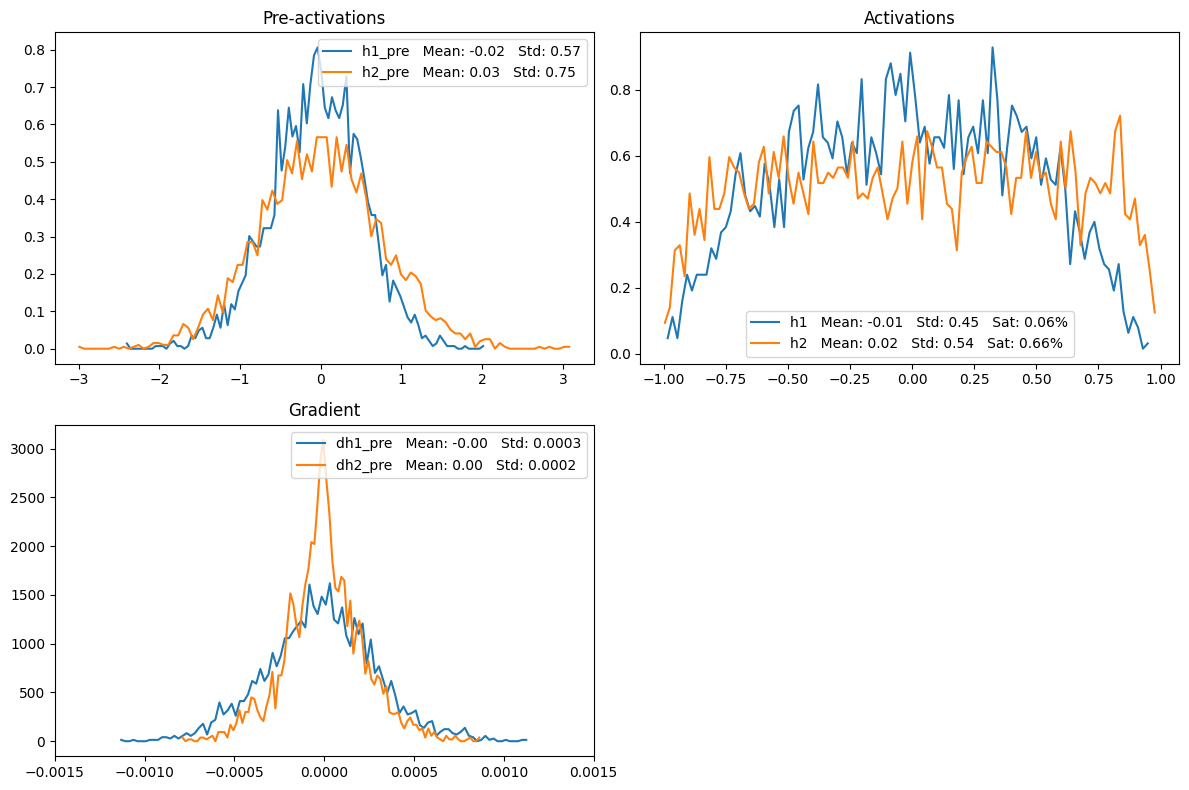

In [ ]:
plt.figure(figsize=(12,8))

# Pre-activations distribution
plt.subplot(221)
hy, hx = torch.histogram(h1_pre, density=True)
plt.plot(hx[:-1].detach(), hy.detach(), label=f'h1_pre   Mean: {h1_pre.mean():.2f}   Std: {h1_pre.std():.2f}')
hy, hx = torch.histogram(h2_pre, density=True)
plt.plot(hx[:-1].detach(), hy.detach(), label=f'h2_pre   Mean: {h2_pre.mean():.2f}   Std: {h2_pre.std():.2f}')
plt.title('Pre-activations')
plt.legend()

# Activations distribution
plt.subplot(222)
hy, hx = torch.histogram(h1, density=True)
plt.plot(hx[:-1].detach(), hy.detach(), label=f'h1   Mean: {h1.mean():.2f}   Std: {h1.std():.2f}   Sat: {(h1.abs() > 0.97).float().mean()*100:.2f}%')
hy, hx = torch.histogram(h2, density=True)
plt.plot(hx[:-1].detach(), hy.detach(), label=f'h2   Mean: {h2.mean():.2f}   Std: {h2.std():.2f}   Sat: {(h2.abs() > 0.97).float().mean()*100:.2f}%')
plt.title('Activations')
plt.legend()

# Gradients distribution
plt.subplot(223)
hy, hx = torch.histogram(h1_pre.grad, density=True)
plt.plot(hx[:-1].detach(), hy.detach(), label=f'dh1_pre   Mean: {h1_pre.grad.mean():.2f}   Std: {h1_pre.grad.std():.4f}')
hy, hx = torch.histogram(h2_pre.grad, density=True)
plt.plot(hx[:-1].detach(), hy.detach(), label=f'dh2_pre   Mean: {h2_pre.grad.mean():.2f}   Std: {h2_pre.grad.std():.4f}')
plt.title('Gradient')
plt.xlim(-0.0015, 0.0015)
plt.legend()

plt.tight_layout()

In [27]:
# Initialize neural network
parameters = initialize_nn()
W1, b1, W2, b2, W3, b3 = parameters
log = ""


# Train model
for epoch in range(epochs):

    running_train_loss = 0

    for Xb, Yb in train_loader:

        Xb = Xb.view(-1,784)

        # Forward pass
        h1 = torch.tanh(Xb @ W1 + b1)
        h2 = torch.tanh(h1 @ W2 + b2)
        logits = h2 @ W3 + b3

        # Calculate loss
        loss = F.cross_entropy(logits, Yb)
        running_train_loss += loss.item()

        # Backward pass
        for p in parameters:
            p.grad = None
        loss.backward()

        # Update parameters
        for p in parameters:
            p.data += -lr * p.grad
    
    train_loss = running_train_loss / steps
    log += f"| {epoch+1:^5} | {train_loss:^10.4f} |\n"

print_log(log)

| Epoch | Train Loss |
|-------|------------|
|   1   |   0.3077   |
|   2   |   0.1446   |
|   3   |   0.1017   |
|   4   |   0.0796   |
|   5   |   0.0635   |



Scaling the weights of the last layer and using Kaiming intilization, the accuracy of the model went up to 97%!

In [28]:
test_loss, test_accuracy = evaluate()
print(f"Test Loss: {test_loss:.4f}    Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.0829    Test Accuracy: 97.41%


## nn.Module

&ensp; &ensp; &ensp; &ensp; Let's construct a deeper neural network consisting of four hidden layers. From now on, instead of using tensors to build our networks, we will take a more modular approach. We will build our neural networks using different types of layers as building blocks that are stacked.

```{important}
Until this point we used the word "layer" to refer to a group of neurons and in section 2.1 we said there is 3 types of layers: the input layer, the hidden layers, and the ouptut layer. From now on in the book, when we use the word layer we will be refering to transformations that we are applying one after the other. As we will see, there are many different types of layers: Linear layer, Tanh layer, ReLU layer, Softmax Layer, Batch Normalization layer, Convolutional layer, ...

In [215]:
class MLP(nn.Module):
    def __init__(self, n_hidden=100):
        super().__init__()

        self.fc1 = nn.Linear(784, n_hidden)
        self.tanh1 = nn.Tanh()

        self.fc2 = nn.Linear(n_hidden, n_hidden)
        self.tanh2 = nn.Tanh()

        self.fc3 = nn.Linear(n_hidden, n_hidden)
        self.tanh3 = nn.Tanh()

        self.fc4 = nn.Linear(n_hidden, n_hidden)
        self.tanh4 = nn.Tanh()
        
        self.fc_out = nn.Linear(n_hidden, 10)

        with torch.no_grad():
            g = torch.Generator().manual_seed(1)
            for layer in [self.fc1, self.fc2, self.fc3, self.fc4]:
                nn.init.kaiming_normal_(layer.weight, nonlinearity='tanh', generator=g)
            self.fc_out.weight.mul_(0.01)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten 28x28 → 784
        x = self.tanh1(self.fc1(x))
        x = self.tanh2(self.fc2(x))
        x = self.tanh3(self.fc3(x))
        x = self.tanh4(self.fc4(x))
        x = self.fc_out(x)
        return x

In [216]:
model = MLP()
model

MLP(
  (fc1): Linear(in_features=784, out_features=100, bias=True)
  (tanh1): Tanh()
  (fc2): Linear(in_features=100, out_features=100, bias=True)
  (tanh2): Tanh()
  (fc3): Linear(in_features=100, out_features=100, bias=True)
  (tanh3): Tanh()
  (fc4): Linear(in_features=100, out_features=100, bias=True)
  (tanh4): Tanh()
  (fc_out): Linear(in_features=100, out_features=10, bias=True)
)

In [217]:
model.fc1.weight.shape

torch.Size([100, 784])

## Hooks

PyTorch does not provide a built-in way to automatically access the activations and gradients of the neurons in each layer. To inspect internal computations, PyTorch relies on a system of hooks. I created the Hooks class to record pre-activations and activations during the forward pass, gradients during the backward pass, and to plot them.

In [218]:
class Hooks:
    def __init__(self):
        self.activations = {}
        self.gradients = {}
    
    def save_activation(self, name):
        def hook(module, input, output):
            self.activations[name] = output.detach()
        return hook

    def save_gradient(self, name):
        def hook(module, grad_input, grad_output):
            if grad_output and grad_output[0] is not None:
                self.gradients[name] = grad_output[0].detach()
        return hook
    
    def register_hooks(self, model):
        for name, module in model.named_modules():
            if name == "":
                continue
            module.register_forward_hook(self.save_activation(name))
            if any(p.requires_grad for p in module.parameters(recurse=False)):
                module.register_full_backward_hook(self.save_gradient(name))
    
    def saved_hooks(self):
        print(f"Activations: {list(self.activations.keys())}")
        print(f"Gradients: {list(self.gradients.keys())}")

    def plot_hooks(self):
        plt.figure(figsize=(20, 15))

        # Pre-activations (Linear layers)
        plt.subplot(3, 2, 1)
        for name, tensor in self.activations.items():
            if name.startswith("fc") and name != "fc_out":
                hy, hx = torch.histogram(tensor, density=True)
                plt.plot(hx[:-1].detach(), hy.detach(),
                         label=f'{name}   Mean: {tensor.mean():.2f}   Std: {tensor.std():.2f}')
        plt.title('Pre-activations')
        plt.legend()

        # Post-activations (Tanh layers)
        plt.subplot(3, 2, 2)
        for name, tensor in self.activations.items():
            if name.startswith("tanh"):
                sat = (tensor.abs() > 0.97).float().mean() * 100
                hy, hx = torch.histogram(tensor, density=True)
                plt.plot(hx[:-1].detach(), hy.detach(),
                         label=f'{name}   Mean: {tensor.mean():.2f}   Std: {tensor.std():.2f}   Sat: {sat:.2f}%')
        plt.title('Activations')
        plt.legend()

        # Gradients (Linear layers)
        plt.subplot(3, 2, 3)
        for name, tensor in self.gradients.items():
            if name.startswith("fc") and name != "fc_out":
                hy, hx = torch.histogram(tensor, density=True)
                plt.plot(hx[:-1].detach(), hy.detach(),
                        label=f'{name}   Mean: {tensor.mean():.2e}   Std: {tensor.std():.2e}')
        plt.title('Gradients')
        plt.xlim(-0.00015, 0.00015)
        plt.legend()

        plt.tight_layout()
        plt.show()


In [219]:
# Initialize model
model = MLP()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)
hooks = Hooks()
hooks.register_hooks(model)

# Train model
for epoch in range(epochs):

    for Xb, Yb in train_loader:

        # Forward pass
        logits = model(Xb)

        # Calculate loss
        loss = F.cross_entropy(logits, Yb)
            
        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        break

    break

In [220]:
hooks.saved_hooks()

Activations: ['fc1', 'tanh1', 'fc2', 'tanh2', 'fc3', 'tanh3', 'fc4', 'tanh4', 'fc_out']
Gradients: ['fc_out', 'fc4', 'fc3', 'fc2', 'fc1']


In [221]:
hooks.activations["fc1"].shape

torch.Size([32, 100])

## Vanishing Gradient

&ensp; &ensp; &ensp; &ensp; Please note in the gradient graph that the gradient of the loss with respect to the second layer's pre-activations is smaller than the gradient of the loss with respect to the first layer's pre-activations. This phenomenon, known as the **vanishing gradient** problem, is an issue because the first layer is learning faster than the second layer. As the network depth increases, this problem becomes more pronounced.

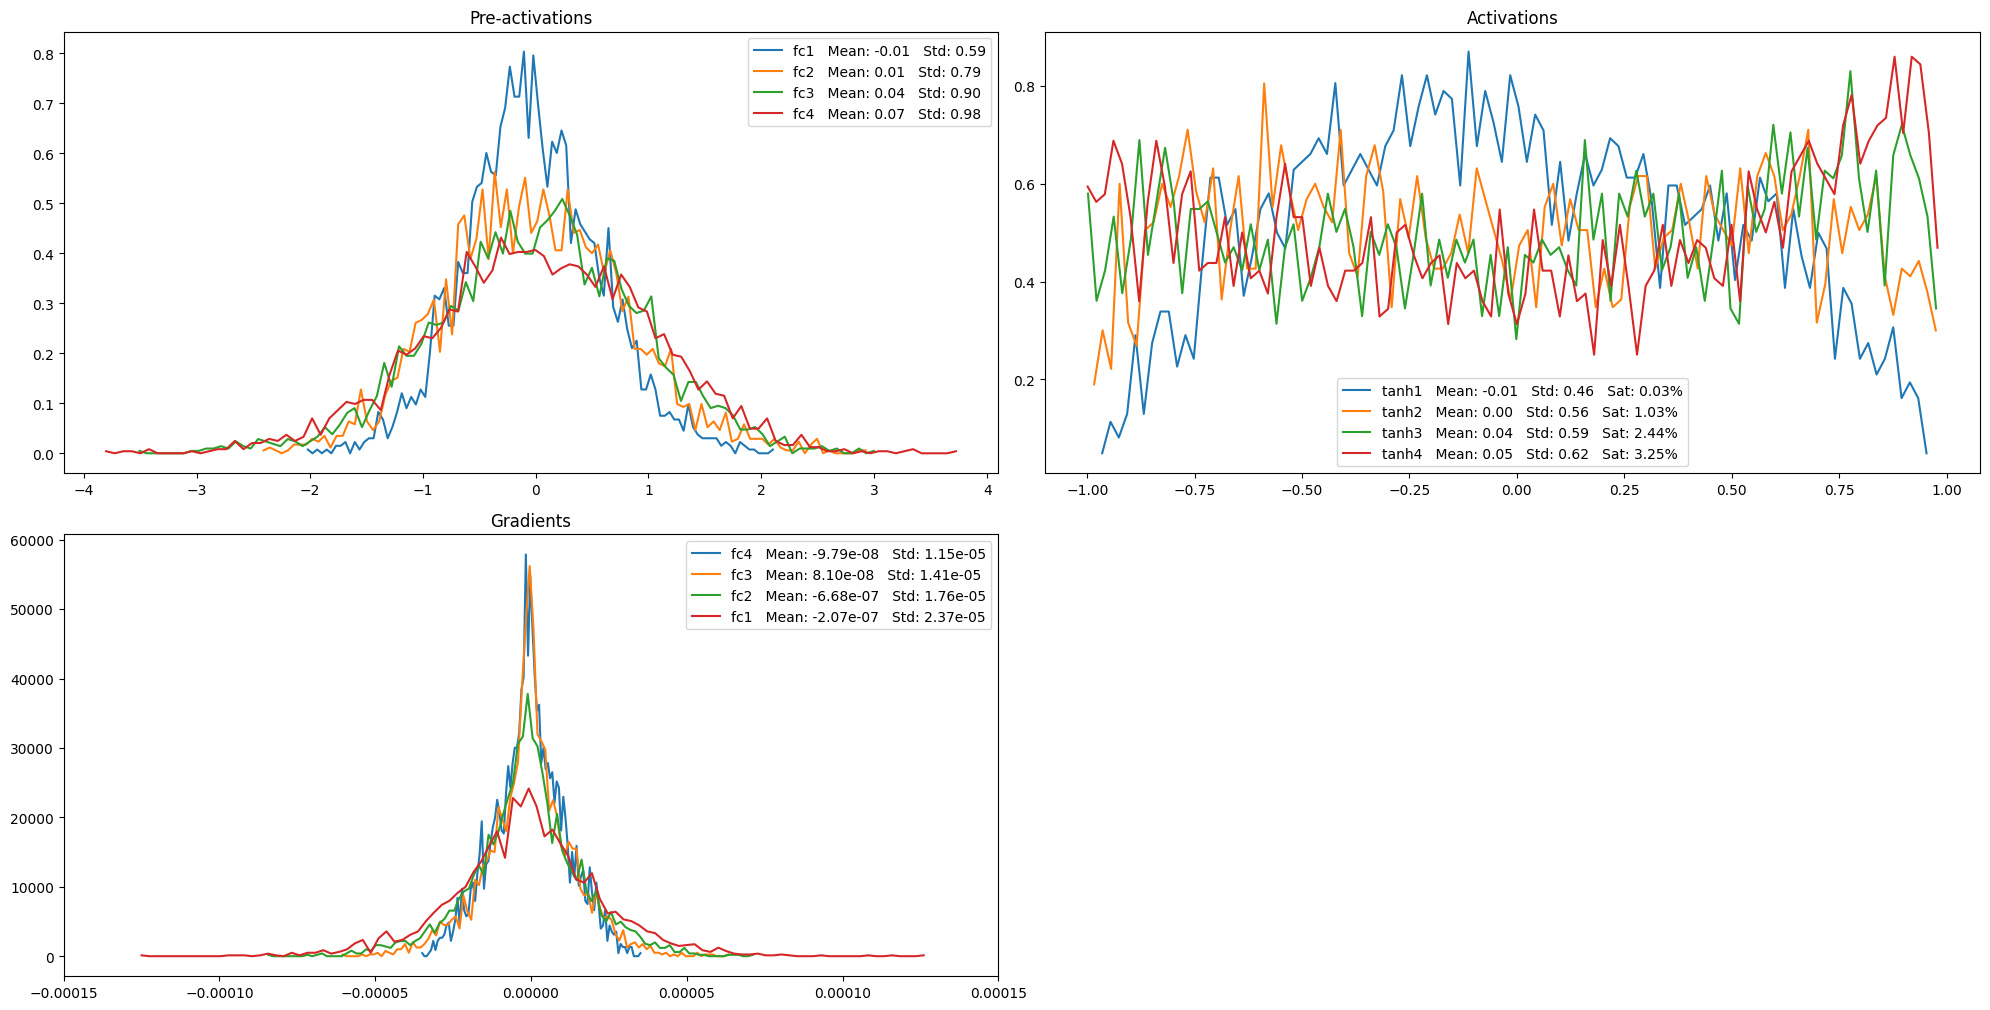

In [222]:
hooks.plot_hooks()

## Batch Normalization

In [223]:
class MLP(nn.Module):
    def __init__(self, n_hidden=100):
        super().__init__()
        self.fc1 = nn.Linear(784, n_hidden, bias=False)
        self.bn1 = nn.BatchNorm1d(n_hidden)
        self.tanh1 = nn.Tanh()

        self.fc2 = nn.Linear(n_hidden, n_hidden, bias=False)
        self.bn2 = nn.BatchNorm1d(n_hidden)
        self.tanh2 = nn.Tanh()

        self.fc3 = nn.Linear(n_hidden, n_hidden, bias=False)
        self.bn3 = nn.BatchNorm1d(n_hidden)
        self.tanh3 = nn.Tanh()

        self.fc4 = nn.Linear(n_hidden, n_hidden, bias=False)
        self.bn4 = nn.BatchNorm1d(n_hidden)
        self.tanh4 = nn.Tanh()
        
        self.fc_out = nn.Linear(n_hidden, 10, bias=False)

        # Weight initialization
        with torch.no_grad():
            for layer in [self.fc1, self.fc2, self.fc3, self.fc4]:
                nn.init.kaiming_normal_(layer.weight, nonlinearity='tanh')
            nn.init.kaiming_normal_(self.fc_out.weight, nonlinearity='tanh')
            self.fc_out.weight *= 0.01

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten 28x28 → 784
        x = self.tanh1(self.bn1(self.fc1(x)))
        x = self.tanh2(self.bn2(self.fc2(x)))
        x = self.tanh3(self.bn3(self.fc3(x)))
        x = self.tanh4(self.bn4(self.fc4(x)))
        x = self.fc_out(x)
        return x

In [224]:
# Initialize model
model = MLP()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)
hooks = Hooks()
hooks.register_hooks(model)

# Train model
for epoch in range(epochs):

    for Xb, Yb in train_loader:

        # Forward pass
        logits = model(Xb)

        # Calculate loss
        loss = F.cross_entropy(logits, Yb)
            
        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        break

    break

In [225]:
hooks.saved_hooks()

Activations: ['fc1', 'bn1', 'tanh1', 'fc2', 'bn2', 'tanh2', 'fc3', 'bn3', 'tanh3', 'fc4', 'bn4', 'tanh4', 'fc_out']
Gradients: ['fc_out', 'bn4', 'fc4', 'bn3', 'fc3', 'bn2', 'fc2', 'bn1', 'fc1']


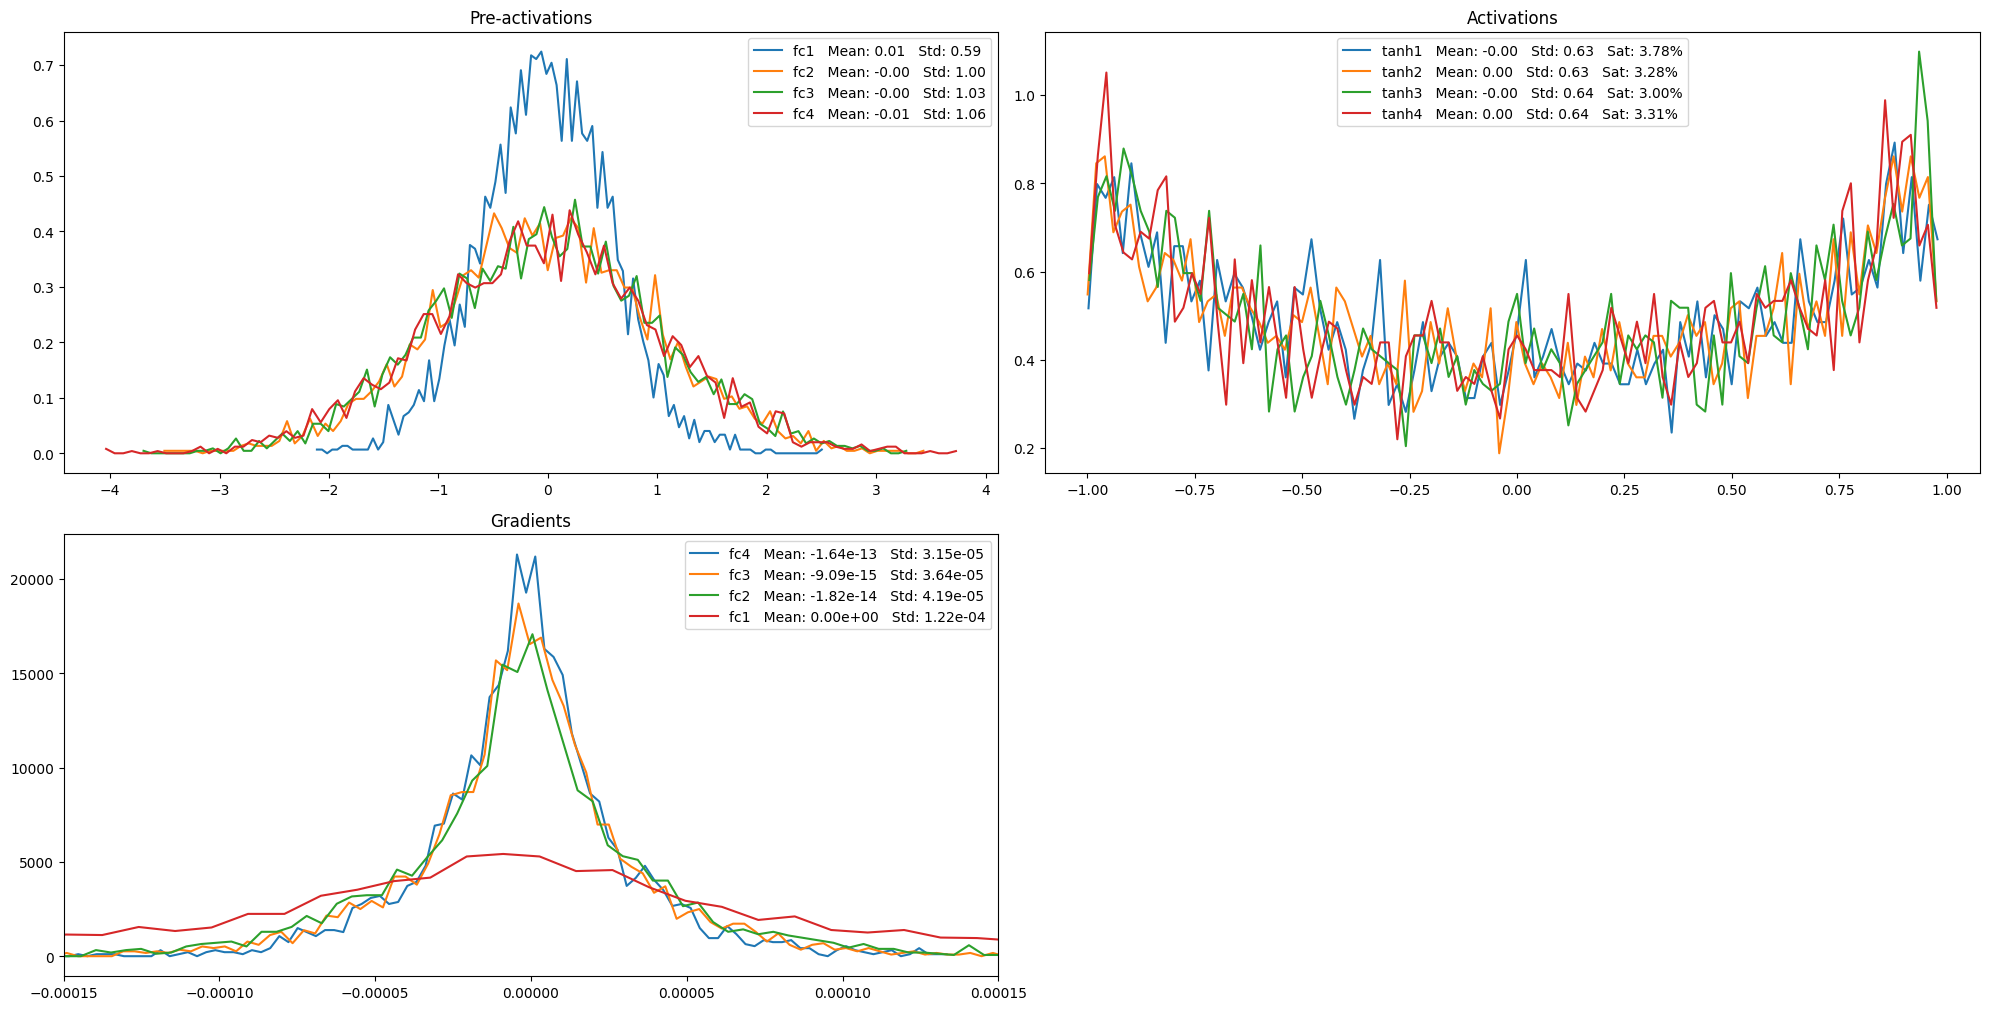

In [226]:
hooks.plot_hooks()

## nn.Sequential

nn.Sequential is a container module in PyTorch that lets you stack layers together. It makes the code more concise and readable by removing the need to define each layer as a separate attribute or to explicitly write the forward pass. It’s useful when the model follows a straight path from input to output without any branches, or skip connections.

In [30]:
class MLP(nn.Module):
    def __init__(self, n_hidden=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784,      n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
            nn.Linear(n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
            nn.Linear(n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
            nn.Linear(n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
            nn.Linear(n_hidden,       10, bias=False),
        )
        
        # Weight initialization
        with torch.no_grad():
            for layer in self.net:
                if isinstance(layer, nn.Linear):
                    nn.init.kaiming_normal_(layer.weight, nonlinearity='tanh')
            self.net[-1].weight *= 0.01  # Scale last layer
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

In [31]:
# Initialize model
model = MLP()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)
log = ""

# Train model
for epoch in range(epochs):

    running_train_loss = 0

    for Xb, Yb in train_loader:

        # Forward pass
        logits = model(Xb)
        
        # Calculate loss
        loss = F.cross_entropy(logits, Yb)
        running_train_loss += loss.item()
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        # Update parameters
        optimizer.step()
    
    train_loss = running_train_loss / len(train_loader)
    log += f"| {epoch+1:^5} | {train_loss:^10.4f} |\n"

print_log(log)

| Epoch | Train Loss |
|-------|------------|
|   1   |   0.3179   |
|   2   |   0.1632   |
|   3   |   0.1235   |
|   4   |   0.0993   |
|   5   |   0.0855   |



In [ ]:
@torch.no_grad()
def evaluate(model, loader):
    """
    Evaluates a PyTorch model on a given DataLoader.

    Args:
        model (nn.Module): The model to evaluate.
        loader (DataLoader): DataLoader containing the dataset (e.g., validation or test).

    Returns:
        tuple (float, float): Average loss and accuracy (between 0 and 1).
    """
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    for Xb, Yb in loader:
        logits = model(Xb)
        loss = F.cross_entropy(logits, Yb, reduction='sum')
        total_loss += loss.item()
        total_correct += (logits.argmax(dim=1) == Yb).sum().item()
        total_samples += Yb.size(0)
    
    return total_loss / total_samples, total_correct / total_samples

In [ ]:
test_loss, test_accuracy = evaluate(model, test_loader)
print(f"Test Loss: {test_loss:.4f}    Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.0778    Test Accuracy: 97.58%
